In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import h5py
import json
import pickle

In [2]:
path_to_hdf5 = '../../../../../../scratch/ROM_datasets_ale/ASTEC/'
path_to_hdf5 = '../../../../../../tudelft.net/staff-umbrella/eldar/ASTEC/ordered_hdf5/'

In [8]:
#get metadata and save them in file

def explore_hdf5(file_path, output_file='hdf5_metadata.txt'):
    with open(output_file, 'w') as out:
        with h5py.File(file_path, 'r') as f:
            # Root-level attributes
            out.write("Root attributes:\n")
            for key, value in f.attrs.items():
                out.write(f"  {key}: {value}\n")
            
            # Explore all datasets and their metadata
            def print_attrs(name, obj):
                out.write(f"\n{name}:\n")
                out.write(f"  Type: {type(obj)}\n")
                if isinstance(obj, h5py.Dataset):
                    out.write(f"  Shape: {obj.shape}\n")
                    out.write(f"  Dtype: {obj.dtype}\n")
                # Print attributes
                for key, val in obj.attrs.items():
                    out.write(f"  Attr - {key}: {val}\n")
            
            f.visititems(print_attrs)
    
    print(f"Metadata saved to {output_file}")

# Usage
explore_hdf5(path_to_hdf5 + '/1.h5', 'hdf5_metadata.txt')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../../../../../tudelft.net/staff-umbrella/eldar/ASTEC/ordered_hdf5//1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
with h5py.File(path_to_hdf5+'/data_training.h5', 'r') as f:
    keys = list(f.keys())
    variables = (f[keys[0]].keys())
    for i in keys:
        print(i)
        for x in variables:
            if np.isnan(f[i][x]).any():
                print(x)
                nan_indices = np.where(np.isnan(f[i][x]))
                print(nan_indices)

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '../../../../../../scratch/aalelonghi/ROM_datasets_ale/ASTEC/original_hdf5//data_training.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
with h5py.File(path_to_hdf5+'/63.h5', 'r') as f:
    print(np.shape(f['primary/volume/P_vessel']))

KeyError: "Unable to synchronously open object (object 'P_vessel' doesn't exist)"

In [55]:
with h5py.File(path_to_hdf5+'/data_training.h5', 'r') as f:
    keys = list(f.keys())
    print(np.shape(f[keys[0]]['dictionary_of_input_variables_1']))
    print(f[keys[0]]['dictionary_of_input_variables_1'][0,:,2])

(1, 25454, 4)
[8.6733200e+20 8.6733200e+20 8.6733200e+20 ... 2.0058188e+20 2.0058114e+20
 2.0058076e+20]


Keys: ['other', 'primary', 'secondary', 'vessel', 'connection', 'containment', 'dimensions']
(56100, 140)
32026.975


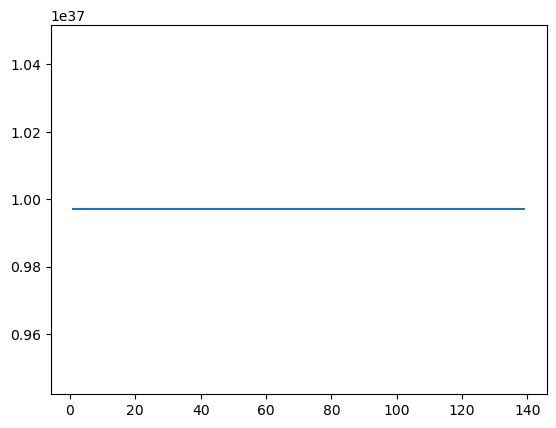

In [7]:
with h5py.File(path_to_hdf5+'/419.h5', 'r') as f:
    print("Keys:", list(f.keys()))
    print(np.shape(f['vessel/face/Q_m_liq_face']))
    print(f['other/global/vessel_rupture_time'][-1])
    plt.plot(f['vessel/face/Q_m_liq_face'][33239])

(48851, 76)


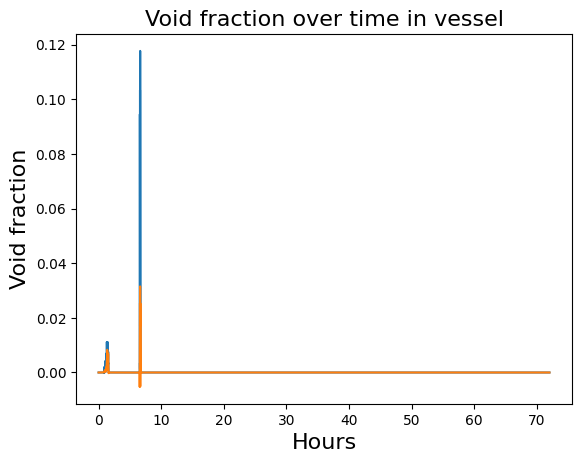

In [20]:
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

with h5py.File(path_to_hdf5+'/1.h5', 'r') as f:
    print(np.shape(f['vessel/mesh/x_alfa_vessel'][:]))
    data = f['connection/fission/Q_fp_Sr'][:]
    plt.plot(f['dimensions/time_points'][:]/3600, data)
    
    smoothed = savgol_filter(data, window_length=200, polyorder=3)
    plt.plot(f['dimensions/time_points'][:]/3600, smoothed)
    
    smoothed = gaussian_filter1d(data, sigma=20)
    
    #plt.plot(f['dimensions/time_points'][:]/3600, smoothed)
    
    plt.xlabel('Hours', fontsize = 16)
    plt.ylabel('Void fraction', fontsize = 16)
    plt.title('Void fraction over time in vessel', fontsize = 16)
    plt.savefig('void_fraction.png', dpi=300, bbox_inches='tight')

In [7]:
operator_names = ['t_fbseb', 't1_srv', 'opensrv', 't2_srv', 'tendssg2', 'tpesp','tpessg', 'tcss', 'p_u5', 'tsg2tr']
with h5py.File(path_to_hdf5+'/'+str(603)+'.h5', 'r') as f:
    for i in operator_names:
        print(f[f'other/private/{i}'][0])

18157.959
2554.9316
31.518555
29796.143
16048.633
27762.451
27095.947
1000000000.0
580151.4
15948.633


In [10]:
operator_names = ['t_fbseb', 't1_srv', 'opensrv', 't2_srv', 'tendssg2', 'tpesp','tpessg', 'tcss', 'p_u5', 'tsg2tr']
with h5py.File(path_to_hdf5+'/'+str(1)+'.h5', 'r') as f:
    for i in operator_names:
        print(f[f'other/private/{i}'][1])

1250.0
6250.0
87.5
8750.0
1000000000.0
5687.5
1000000000.0
13950.0
537500.0
1000000000.0


In [8]:
operator_names = ['t_fbseb', 't1_srv', 'opensrv', 't2_srv', 'tendssg2', 'tpesp','tpessg', 'tcss', 'p_u5', 'tsg2tr']
with h5py.File(path_to_hdf5+'/'+str(774)+'.h5', 'r') as f:
    for i in operator_names:
        print(f[f'other/private/{i}'][0])

18554.688
10117.1875
27.34375
30351.562
12643.75
22695.312
19414.062
1000000000.0
503906.25
12543.75


LOCA_KIT_CESAR_in_ou_s994
[0.]
(1,)
nan


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../../../../../tudelft.net/staff-umbrella/eldar/ASTEC/original_hdf5/84f0f911-0f1d-45f7-a988-a6cb0b3021d5.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

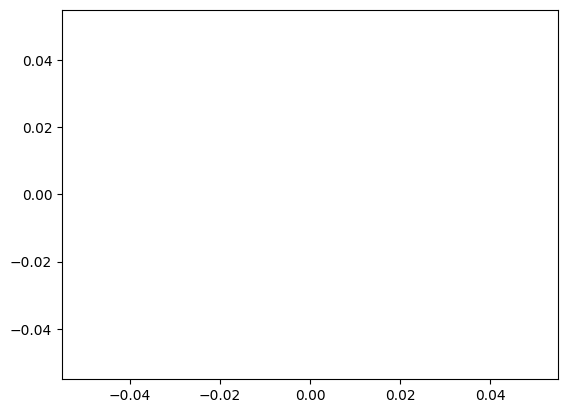

In [3]:
with h5py.File('../../../../../../tudelft.net/staff-umbrella/eldar/ASTEC/ordered_hdf5/397.h5', 'r') as f:
    print(f.attrs['archive_name'].decode('utf-8'))
    print(f['dimensions/time_points'][:])
    print(np.shape(f['vessel/mesh/x_alfa_vessel'][:][:,0]))
    print(f['other/global/vessel_rupture_time'][:][-1]/3600)
    plt.plot(f['dimensions/time_points'][:])
    
with h5py.File('../../../../../../tudelft.net/staff-umbrella/eldar/ASTEC/original_hdf5/84f0f911-0f1d-45f7-a988-a6cb0b3021d5'+'.h5', 'r') as f:
    print(np.shape(f['vessel/mesh/x_alfa_vessel'][:][:,0]))
    print(f.attrs['archive_name'].decode('utf-8'))
    print(f['dimensions/time_points'][:])
    print(f['other/global/vessel_rupture_time'][:][-1]/3600)
    plt.plot(f['dimensions/time_points'][:])

In [6]:
for j in range(1):
    with h5py.File(path_to_hdf5+'/'+str(j+1)+'.h5', 'r') as f:
        t_rupture = f['other/global/vessel_rupture_time'][:][-1]/3600
        if t_rupture>20:
            print(t_rupture)
        print(f['vessel/face/Q_m_liq_face'][:])

[[ 2.3641023e+03  6.5491958e+03  1.0088857e+04 ...  1.0103093e+04
   3.6953137e+02 -1.9371688e+04]
 [ 2.2359424e+03  6.1994253e+03  9.5472549e+03 ...  9.6981123e+03
   3.8344507e+02 -1.8160631e+04]
 [ 2.2219409e+03  6.1600181e+03  9.4868291e+03 ...  9.6201611e+03
   3.8539203e+02 -1.8093766e+04]
 ...
 [           nan  9.9692100e+36  9.9692100e+36 ...  9.9692100e+36
   9.9692100e+36  9.9692100e+36]
 [           nan  9.9692100e+36  9.9692100e+36 ...  9.9692100e+36
   9.9692100e+36  9.9692100e+36]
 [           nan  9.9692100e+36  9.9692100e+36 ...  9.9692100e+36
   9.9692100e+36  9.9692100e+36]]


(49095,)
[14784.326 14785.326 14786.326 14787.326 14788.326 14789.326 14790.326
 14791.326 14792.326 14793.326 14794.326 14795.326 14796.326 14797.326
 14798.326 14799.326 14800.326 14801.326 14802.326 14803.326 14804.326
 14805.326 14806.326 14807.326 14808.326 14809.326 14810.326 14811.326
 14812.326 14813.326 14814.326 14815.326 14816.326 14817.326 14818.326
 14819.326 14820.326 14821.326 14822.326 14823.326 14824.326 14825.326
 14826.326 14827.326 14828.326 14829.326 14830.326 14831.326 14832.326
 14833.326 14834.326 14835.326 14836.326 14837.326 14838.326 14839.326
 14840.326 14841.326 14842.326 14843.326 14844.326 14845.326 14846.326
 14847.326 14848.326 14849.326 14850.326 14851.326 14852.326 14853.326
 14854.326 14855.326 14856.326 14857.326 14858.326 14859.326 14860.326
 14861.326 14862.326 14863.326 14864.326 14865.326 14866.326 14867.326
 14868.326 14869.326 14870.326 14871.326 14872.326 14873.326 14874.326
 14875.326 14876.326 14877.326 14878.326 14879.326 14880.326 14881.3

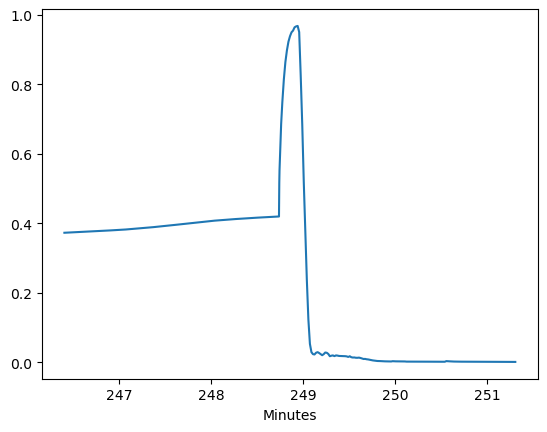

In [21]:
with h5py.File(path_to_hdf5+'/1.h5', 'r') as f:
    print(np.shape(f['vessel/mesh/x_alfa_vessel'][:][:,0]))
    print(f['dimensions/time_points'][:][16000:16300])
    plt.plot(f['dimensions/time_points'][:][16000:16300]/60, f['vessel/mesh/x_alfa_vessel'][:][16000:16300,0])
    plt.xlabel('Minutes')

In [92]:
with h5py.File(path_to_hdf5+'/1.h5', 'r') as f:
    print(np.shape(f['vessel/general/T_comp_fuel'][:]))
    print((f['vessel/general/T_comp_fuel'][20000]))

(49095, 36)
[1043.6967   838.0785   501.2382  2355.4136   663.2432  2360.0505
 1246.412   1388.8893  2675.2725  1087.9701  1334.2069  1836.666
 1642.8625  1691.9216  1322.2515  1555.0588  1191.457   1269.2622
 1320.5033   652.89923 1252.0764   432.83606  901.1507  1061.3601
  727.90686  753.99646  909.3081   763.6509   894.70557  972.08405
  830.93207  924.26855  866.797    913.6755  1386.4517   855.62177]


In [93]:
with h5py.File(path_to_hdf5+'/4.h5', 'r') as f:
    print(np.shape(f['vessel/general/T_comp_fuel'][:]))
    print((f['vessel/general/T_comp_fuel'][20000]))

(22558, 36)
[1230.175    482.4163  1840.4081  1850.9631   519.9952  2698.655
 2629.5     1606.8716   481.49225  481.21857 2389.3982   502.57098
  500.42798  495.53134  498.3877   498.82367  499.95975  520.3325
  503.76868  502.12115  504.8257   480.68765  510.99612  511.29083
  528.07056  523.9009  1114.4559   806.842   1044.3641   878.0767
  529.591    518.4854   693.98694  484.05502  736.1837   573.17615]


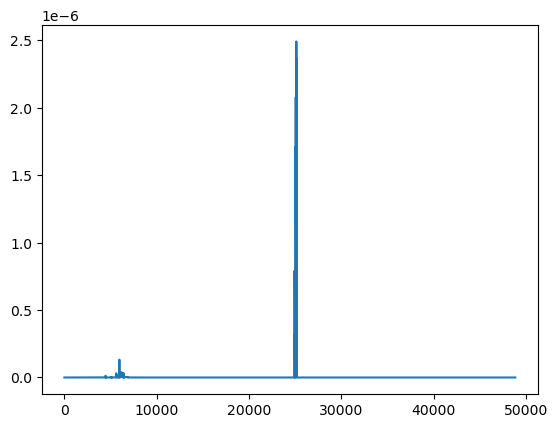

In [8]:
with h5py.File(path_to_hdf5+'/1.h5', 'r') as f:
    plt.plot(f['connection/fission/Q_fp_In'][:])

In [60]:
with h5py.File(path_to_hdf5+'/data_training_normalized_t_W_500.h5', 'r') as f:
    print(f['boundary_conditions_and_time'][0][1])

[1.93716875e+04 5.72605699e-04 5.81186752e+08 1.93716875e+04
 5.72556979e-04 5.81185664e+08 1.00000001e-01]


In [8]:
import torch as tc
a = tc.tensor([[[1,2,3],
                [4,5,6],
                [7,8,9]],
               [[10,11,12],
                [13,14,15],
                [16,17,18]]])
print(a.size())
lenght_padding = [1,2]

torch.Size([2, 3, 3])


In [16]:
import torch as tc

a = tc.tensor([[[1,2,3],
                [4,5,6],
                [7,8,9]],
               [[10,11,12],
                [13,14,15],
                [16,17,18]]])

length_padding = [1, 2]

# Create a mask for valid positions
batch_size, num_rows, num_cols = a.size()
length_padding_tensor = tc.tensor(length_padding)

# Create column indices [0, 1, 2] for each position
col_indices = tc.arange(num_cols).unsqueeze(0).unsqueeze(0)  # shape: [1, 1, 3]
print(col_indices)
# Create mask where column index < length_padding for each batch
# Need to broadcast to [batch_size, num_rows, num_cols]
mask = col_indices < length_padding_tensor.view(-1, 1, 1)  # shape: [2, 1, 3]
print(mask)
mask = mask.expand(batch_size, num_rows, num_cols)  # shape: [2, 3, 3]
print(mask)
# Apply mask and extract valid elements
output = a[mask]
print(output)
print(output)  # tensor([ 1,  4,  7, 10, 11, 13, 14, 16, 17])


tensor([[[0, 1, 2]]])
tensor([[[ True, False, False]],

        [[ True,  True, False]]])
tensor([[[ True, False, False],
         [ True, False, False],
         [ True, False, False]],

        [[ True,  True, False],
         [ True,  True, False],
         [ True,  True, False]]])
tensor([ 1,  4,  7, 10, 11, 13, 14, 16, 17])
tensor([ 1,  4,  7, 10, 11, 13, 14, 16, 17])


<KeysViewHDF5 ['boundary_conditions_and_time', 'dictionary_of_input_variables_1', 'dictionary_of_input_variables_140', 'dictionary_of_input_variables_36', 'dictionary_of_input_variables_76', 'length_of_padding', 'lower_plenum']>
(722306, 10, 4, 12, 3)


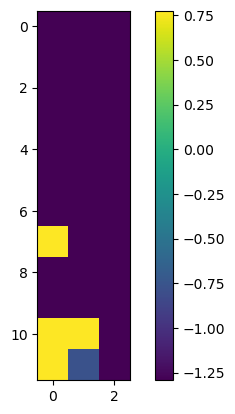

In [32]:
with h5py.File(path_to_hdf5+'/data_training_normalized_t_W_10_1_153_192_396_398_500.h5', 'r') as f:
    print(f.keys())
    print(np.shape(f['dictionary_of_input_variables_36']))
    plt.imshow(f['dictionary_of_input_variables_36'][500][-1][2])
    plt.colorbar()
    